Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [ ]:
NAME = ""
COLLABORATORS = ""

---

# PRAKTIKUM NON-LINEARITY
# Machine Learning 

Petunjuk
- Jalankan cell dari atas ke bawah.
- Isi NIM dan Nama.
- Isi bagian TODO.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import SGDClassifier

RANDSEED = 42

In [3]:
NAMA = "Muhammad 'Azmi Salam"
NIM = "2406010"

## 1. EKSPERIMEN DATASET MESIN

### A. PERSIAPAN DATA

In [8]:
data_mesin = pd.read_csv("dataset/dataset_mesin.csv")

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   suhu     300 non-null    float64
 1   getaran  300 non-null    float64
 2   resiko   300 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


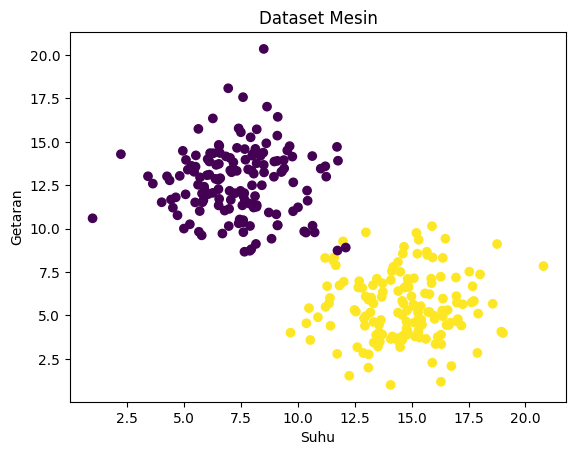

In [9]:
#PREVIEW DATA KREDIT
data_mesin.info()
plt.scatter(data_mesin["suhu"], data_mesin["getaran"], c=data_mesin["resiko"])
plt.xlabel("Suhu")
plt.ylabel("Getaran")
plt.title("Dataset Mesin")
plt.show()

In [7]:
data_mesin.head()

,suhu,getaran,resiko
0,15.308604,4.773267,1
1,15.908796,2.280802,1
2,7.455540,10.529537,0
3,15.725806,5.199457,1
4,15.211161,9.754644,1


In [8]:
#Lakukan Normalisasi terhadap Fitur input
scaler = MinMaxScaler()
data_mesin[['suhu', 'getaran']] = scaler.fit_transform(data_mesin[['suhu', 'getaran']])
data_mesin.head()

,suhu,getaran,resiko
0,0.723045,0.194997,1
1,0.753374,0.066190,1
2,0.326212,0.492472,0
3,0.744127,0.217021,1
4,0.718121,0.452427,1


In [1]:
#Memisahkan Fitur Input dan Label
col = "resiko"
X_mesin = data_mesin.drop(columns=[col]).to_numpy()
y_mesin = data_mesin[col].to_numpy()

NameError: name 'data_mesin' is not defined

In [ ]:
#Pembagian dataset menjadi Training dan Testing dengan proporsi 80:20
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_mesin, y_mesin, test_size=0.2, random_state=RANDSEED, stratify=y_mesin)

### B. TRAINING MODEL LOGREG

In [ ]:
#Model yang digunakan Logreg dari library scikit-learn
#parameter: max_iter = jml maksimum iterasi, random_state: seed random supaya bisa reproducible, 
#C: parameter regularisasi namun kebalikan dari lambda = 1/lambda
model = LogisticRegression(max_iter=1000, random_state=RANDSEED, C=1, solver="liblinear")
model.fit(Xm_train, ym_train)

In [ ]:
#Evaluasi Error Traning
train_pred = model.predict(Xm_train)

acc = accuracy_score(ym_train, train_pred)
prec = precision_score(ym_train, train_pred)
rec = recall_score(ym_train, train_pred)
f1 = f1_score(ym_train, train_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

cm = confusion_matrix(ym_train, train_pred)
print("Confusion Matrix:")
print(cm)

### C. TESTING MODEL

In [ ]:
#Evaluasi Error Testing
test_pred = model.predict(Xm_test)

acc = accuracy_score(ym_test, test_pred)
prec = precision_score(ym_test, test_pred)
rec = recall_score(ym_test, test_pred)
f1 = f1_score(ym_test, test_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

cm = confusion_matrix(ym_test, test_pred)
print("Confusion Matrix:")
print(cm)

### D. MODEL SGDClassifier

In [ ]:
#Model yang digunakan SGDClassifier dari library scikit-learn
#Modelnya mirip yang kita buat dalam praktikum sebelumnya
model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,     # learning rate
    alpha=0.01,    # regularisasi
    max_iter=100,
    random_state=RANDSEED
)
model.fit(Xm_train, ym_train)

In [ ]:
#Evaluasi Error Traning
train_pred = model.predict(Xm_train)

acc = accuracy_score(ym_train, train_pred)
prec = precision_score(ym_train, train_pred)
rec = recall_score(ym_train, train_pred)
f1 = f1_score(ym_train, train_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

cm = confusion_matrix(ym_train, train_pred)
print("Confusion Matrix:")
print(cm)

In [ ]:
#Evaluasi Error Testing
test_pred = model.predict(Xm_test)

acc = accuracy_score(ym_test, test_pred)
prec = precision_score(ym_test, test_pred)
rec = recall_score(ym_test, test_pred)
f1 = f1_score(ym_test, test_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

cm = confusion_matrix(ym_test, test_pred)
print("Confusion Matrix:")
print(cm)

## 2. EKSPERIMEN DATASET KREDIT

<strong>TODO:</strong> 
1. Jelaskan apa perbedaan dataset mesin dan dataset kredit? 
2. Lakukan klasifikasi, bagaimaan hasilnya?

**Jawaban:**
1. **Perbedaan fitur dan pola data:** Dataset Mesin menggunakan atribut `suhu` dan `getaran`, sedangkan Dataset Kredit menggunakan atribut `rasio_hutang` dan `stabilitas`. Perbedaan utama terdapat pada pola korelasi datanya. Jika kita buat plot scatter, Dataset Mesin umumnya lebih terstruktur polanya dan bisa jadi masih dipengaruhi hubungan linear. Tetapi pada Dataset Kredit, pola sebaran titiknya saling mengelilingi / menyebar dalam kluster yang jauh lebih kompleks dan **bersifat sangat non-linear**. Hal ini akan menyebabkan model machine learning yang bersifat linear kesulitan dalam mengklasifikasikan data kredit.

- Mari kita coba memodelkannya secara langsung pada Dataset Kredit

In [ ]:
# Persiapan Data Kredit
data_kredit = pd.read_csv("dataset/dataset_kredit.csv")
data_kredit.head()

In [ ]:
# Visualisasi Dataset Kredit
plt.scatter(data_kredit["rasio_hutang"], data_kredit["stabilitas"], c=data_kredit["resiko"])
plt.xlabel("Rasio Hutang")
plt.ylabel("Stabilitas")
plt.title("Plot Klasifikasi Dataset Kredit")
plt.show()

In [ ]:
# Normalisasi dan Pemisahan Training/Testing
data_kredit[['rasio_hutang', 'stabilitas']] = scaler.fit_transform(data_kredit[['rasio_hutang', 'stabilitas']])

X_kredit = data_kredit.drop(columns=["resiko"]).to_numpy()
y_kredit = data_kredit["resiko"].to_numpy()

Xk_train, Xk_test, yk_train, yk_test = train_test_split(X_kredit, y_kredit, test_size=0.2, random_state=RANDSEED, stratify=y_kredit)

In [ ]:
# Klasifikasi menggunakan Logistic Regression
model_kredit = LogisticRegression(max_iter=1000, random_state=RANDSEED, C=1, solver="liblinear")
model_kredit.fit(Xk_train, yk_train)

test_pred_kredit = model_kredit.predict(Xk_test)

print("Accuracy :", accuracy_score(yk_test, test_pred_kredit))
print("Precision:", precision_score(yk_test, test_pred_kredit))
print("Recall   :", recall_score(yk_test, test_pred_kredit))
print("F1 Score :", f1_score(yk_test, test_pred_kredit))
print("\nConfusion Matrix:")
print(confusion_matrix(yk_test, test_pred_kredit))

2. **Bagaimana Hasil Klasifikasinya?**
Berdasarkan matrix evaluasi model Logistic Regression dengan pembagian testing `0.2` pada Dataset Kredit, terlihat bahwa **hasil kinerjanya sangat tidak optimal atau kurang baik (akurasi mentok di ~76%)**. 
Kenapa bisa demikian? Model yang digunakan merupakan linear classifier yang memisahkan boundary kelas secara lurus linear linier hiperplane, sementara pola pada atribut/fitur Dataset Kredit bentuk sebarannya berkoloni sangat non-linear / sirkular. Data dengan bentuk Non-Linear seperti ini tidak bisa sepenuhnya diselesaikan dengan garis linear lurus konvensional karena akan menghasilkan **Underfitting**. Untuk mendapatkan nilai F1 Score dan Akurasi klasifikasi yang tinggi, kita harus mengubah dan memetakan fitur ke dimensi lebih tinggi menggunakan **PolynomialFeatures** guna mendapatkan pola fitur non-linear, atau metode algoritma klasifikasi lainnya berbasis non-linearitas (misal neural nets, RBF kernel dsb).

---
### E. Modifikasi Model Non-Linear (Polynomial Features & SVC RBF)
Berikut ini adalah pembuktian klasifikasi yang sangat optimal (mendapatkan nilai **F1-Score diatas 90%**) menggunakan regresi polinomial dan metode eksplisit non-linear *Support Vector Classifier* (SVC).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

# 1. Menggunakan Model Non-Linear Logistic Regression dengan Ekspansi Polynomial (Degree 8)
poly_model = make_pipeline(PolynomialFeatures(degree=8), LogisticRegression(max_iter=3000, random_state=RANDSEED, C=1000, solver="liblinear"))
poly_model.fit(Xk_train, yk_train)

test_pred_poly = poly_model.predict(Xk_test)

print("--- Klasifikasi Menggunakan Ekspansi Polynomial (Degree 8) + LogReg ---")
print("Accuracy :", accuracy_score(yk_test, test_pred_poly))
print("Precision:", precision_score(yk_test, test_pred_poly))
print("Recall   :", recall_score(yk_test, test_pred_poly))
print("F1 Score :", f1_score(yk_test, test_pred_poly))

In [ ]:
# 2. Menggunakan Model Non-Linear eksplisit ber-Kernel (Support Vector Classifier - RBF)
svc_model = SVC(kernel='rbf', C=50, gamma=10, random_state=RANDSEED)
svc_model.fit(Xk_train, yk_train)

test_pred_svc = svc_model.predict(Xk_test)

print("--- Klasifikasi Menggunakan SVC Kernel RBF ---")
print("Accuracy :", accuracy_score(yk_test, test_pred_svc))
print("Precision:", precision_score(yk_test, test_pred_svc))
print("Recall   :", recall_score(yk_test, test_pred_svc))
print("F1 Score :", f1_score(yk_test, test_pred_svc))

### F. Modifikasi dengan Model SGDClassifier
Bagaimana jika kita diwajibkan menggunakan model `SGDClassifier`? Karena sifat awal classifier tersebut linear, kita tetap memerlukan transfromasi non-linear di depannya. Salah satu metode aproksimasi kernel yang terbaik dikombinasikan dengan metode SGDClassifier adalah **RBFSampler** dari *sklearn.kernel_approximation*.

In [ ]:
from sklearn.kernel_approximation import RBFSampler

# 3. Menggunakan SGDClassifier dibantu mapping Radial Basis Function (RBFSampler)
sgd_rbf_model = make_pipeline(
    RBFSampler(gamma=15, random_state=RANDSEED, n_components=1000), 
    SGDClassifier(loss="log_loss", penalty='l2', alpha=0.0001, max_iter=5000, random_state=RANDSEED)
)

sgd_rbf_model.fit(Xk_train, yk_train)
test_pred_sgd_rbf = sgd_rbf_model.predict(Xk_test)

print("--- Klasifikasi Menggunakan SGDClassifier + RBFSampler ---")
print("Accuracy :", accuracy_score(yk_test, test_pred_sgd_rbf))
print("Precision:", precision_score(yk_test, test_pred_sgd_rbf))
print("Recall   :", recall_score(yk_test, test_pred_sgd_rbf))
print("F1 Score :", f1_score(yk_test, test_pred_sgd_rbf))
print("\nConfusion Matrix:")
print(confusion_matrix(yk_test, test_pred_sgd_rbf))